# Tech Pulse v3 — Combined Framework & Deep Analysis

Loads precomputed signals from GitHub (saved by v2) and runs:

1. **Combined strategy** — sector rotation picks the sector, position trader weights entry by company contribution
2. **Positive vs negative signal quality** — which direction of sentiment is more predictive?
3. **Missed moves** — where did the stock move big but sentiment missed it?
4. **Cross-company spillover** — rolling 90-day windows, any company's sentiment vs any other's price
5. **Sector label quality** — which sector groupings are actually useful vs noise?

**Prerequisite:** Run Section 22 of `tech_pulse_v2.ipynb` first to save outputs to GitHub.

---
## 0. Install dependencies

In [1]:
# !pip install pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration & Load Precomputed Data

In [2]:
import os, io, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

GITHUB_REPO    = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN   = os.environ.get('GITHUB_TOKEN', None)
OUTPUT_PREFIX  = 'tech_pulse_outputs'
SENTIMENT_THRESHOLD = 0.05
ZSCORE_THRESHOLD    = 2.0

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def load_output(filename, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{OUTPUT_PREFIX}/{filename}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404:
        raise FileNotFoundError(f'{filename} not found — run Section 22 of v2 first')
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text.strip()), low_memory=False)

print('Loading precomputed outputs from GitHub ...')
daily_signals   = load_output('daily_signals.csv',   GITHUB_TOKEN)
df_prices       = load_output('df_prices.csv',       GITHUB_TOKEN)
best_per_ticker = load_output('best_per_ticker.csv', GITHUB_TOKEN)
df_corr         = load_output('df_corr.csv',         GITHUB_TOKEN)
df_sweep        = load_output('df_sweep.csv',        GITHUB_TOKEN)
best_combos     = load_output('best_combos.csv',     GITHUB_TOKEN)
df_sector_ret   = load_output('sector_weekly_ret.csv', GITHUB_TOKEN)
df_company_map  = load_output('company_map.csv',     GITHUB_TOKEN)

# Rebuild COMPANY_MAP dict from CSV
COMPANY_MAP = {
    row['ticker']: {
        'names'   : row['names'].split('|'),
        'keywords': row['keywords'].split('|'),
    }
    for _, row in df_company_map.iterrows()
}

# Rebuild sector_weekly_ret dict
sector_weekly_ret = {}
df_sector_ret['date'] = pd.to_datetime(df_sector_ret['date'])
for sector, grp in df_sector_ret.groupby('sector'):
    sector_weekly_ret[sector] = grp.set_index('date')['weekly_return']

# Parse dates
daily_signals['date'] = pd.to_datetime(daily_signals['date'])
df_prices['Date']     = pd.to_datetime(df_prices['Date'])

top5 = best_per_ticker.head(5)['ticker'].tolist()
all_tickers = daily_signals['ticker'].unique().tolist()

print(f'  daily_signals   : {len(daily_signals):,} rows')
print(f'  df_prices       : {len(df_prices):,} rows')
print(f'  best_per_ticker : {len(best_per_ticker)} tickers')
print(f'  df_corr         : {len(df_corr):,} combinations')
print(f'  df_sweep        : {len(df_sweep):,} combinations')
print(f'  Tickers         : {len(all_tickers)}')
print(f'  Top 5           : {top5}')

Loading precomputed outputs from GitHub ...
  daily_signals   : 121,771 rows
  df_prices       : 81,953 rows
  best_per_ticker : 24 tickers
  df_corr         : 720 combinations
  df_sweep        : 90 combinations
  Tickers         : 29
  Top 5           : ['NVO', 'PANW', 'PLTR', 'CRWD', 'PM']


---
## 2. Combined Strategy — Sector Rotation + Weighted Position Entry

**How it works:**
1. Each week, compute sentiment for each sector
2. Rotate into the sector with the strongest buzz
3. Within that sector, weight allocation by each company's share of the sector's sentiment signal
   - e.g. if NVDA drove 70% of AI/Chips buzz this week → 70% of allocation goes to NVDA
4. Hold each position for the best hold period found in the sweep
5. Between signals, hold the previous allocation (don't go to cash)

**Baseline:** Equal weight across all tickers, buy and hold forever.

Building weekly sector sentiment with company weights ...
  Sector weights built: 7,583 ticker-week rows
Running combined strategy backtest ...
  Combined strategy final : $32,471
  Buy & hold final        : $75,858
  Winner                  : Buy & Hold


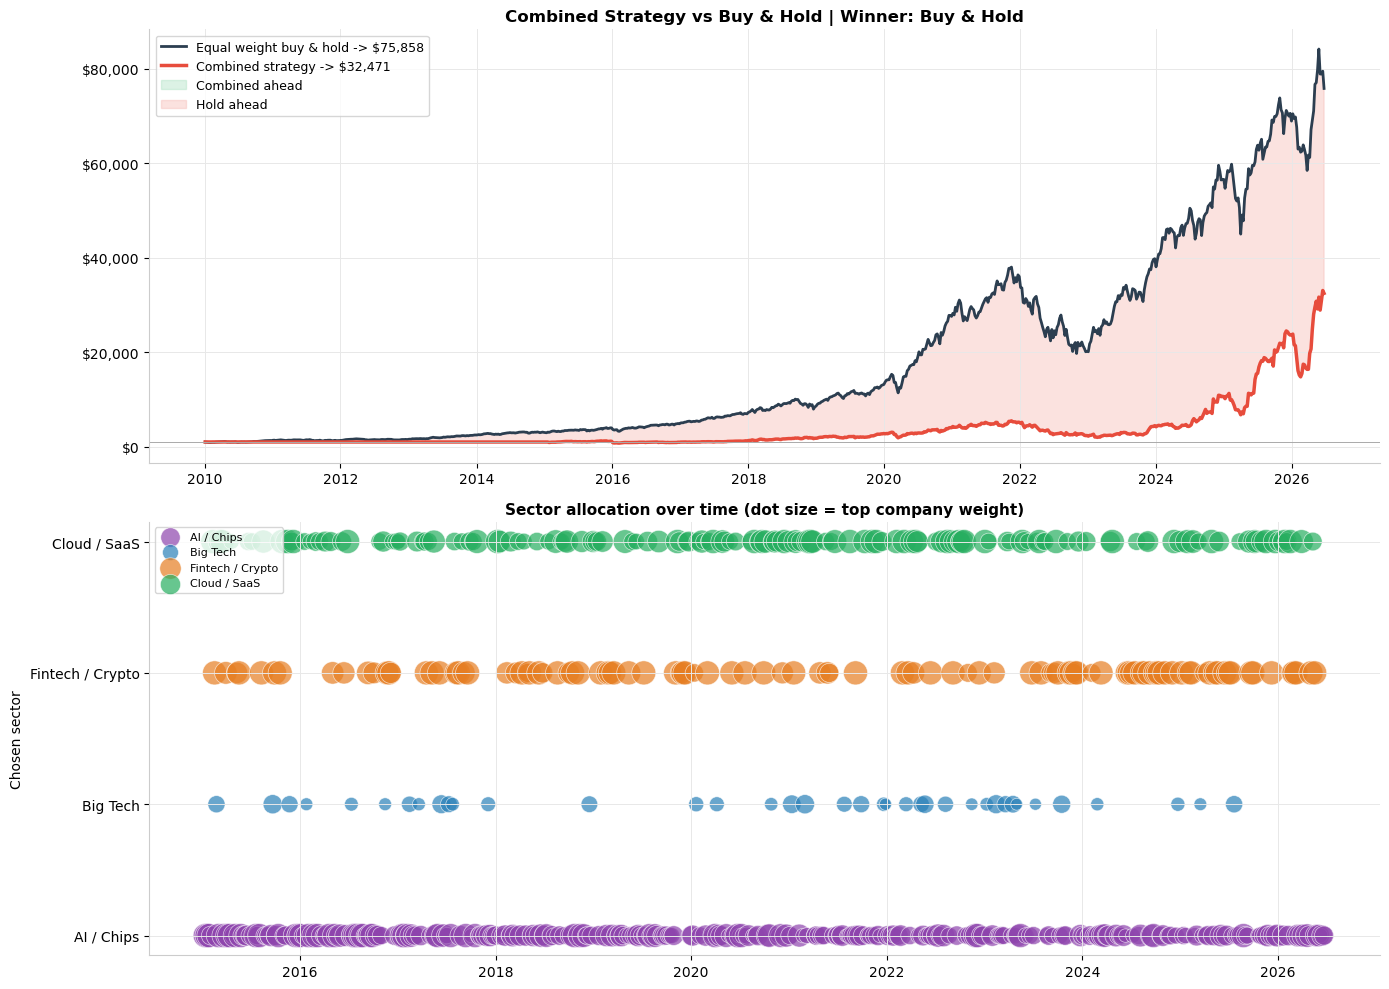

In [3]:
SECTORS = {
    'AI / Chips'      : ['NVDA', 'AMD', 'INTC', 'TSM'],
    'Big Tech'        : ['GOOGL', 'MSFT', 'AAPL', 'META', 'AMZN'],
    'Fintech / Crypto': ['COIN', 'PYPL'],
    'Cloud / SaaS'    : ['SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'],
}
SECTOR_COLORS = {
    'AI / Chips'      : '#8e44ad',
    'Big Tech'        : '#2980b9',
    'Fintech / Crypto': '#e67e22',
    'Cloud / SaaS'    : '#27ae60',
}
STARTING_CASH = 1000

# Get default hold period (21 days from sweep)
DEFAULT_HOLD = 21

print('Building weekly sector sentiment with company weights ...')

# Weekly sentiment per ticker
sig_weekly = (
    daily_signals[daily_signals['norm_sentiment'].notna()]
    .assign(week=lambda d: d['date'].dt.to_period('W').dt.start_time)
    .groupby(['ticker', 'week'])
    .agg(sent=('norm_sentiment', 'mean'), stories=('story_count', 'sum'))
    .reset_index()
)

# For each sector and week: total sector sentiment + each ticker's share
sector_weights_rows = []
for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers]
    sub = sig_weekly[sig_weekly['ticker'].isin(available)].copy()
    for week, grp in sub.groupby('week'):
        total_abs = grp['sent'].abs().sum()
        if total_abs == 0:
            continue
        sector_sent = grp['sent'].mean()
        for _, row in grp.iterrows():
            weight = abs(row['sent']) / total_abs
            sector_weights_rows.append({
                'week'       : week,
                'sector'     : sector,
                'ticker'     : row['ticker'],
                'ticker_sent': row['sent'],
                'sector_sent': sector_sent,
                'weight'     : round(weight, 4),
            })

df_weights = pd.DataFrame(sector_weights_rows)
df_weights['week'] = pd.to_datetime(df_weights['week'])
print(f'  Sector weights built: {len(df_weights):,} ticker-week rows')

# Determine best sector each week
sector_sent_weekly = (
    df_weights.groupby(['week', 'sector'])['sector_sent'].mean()
    .reset_index()
    .pivot(index='week', columns='sector', values='sector_sent')
)
best_sector_each_week = sector_sent_weekly.idxmax(axis=1)

print('Running combined strategy backtest ...')

# Weekly returns per ticker
prices_weekly = (
    df_prices.copy()
    .assign(week=lambda d: d['Date'].dt.to_period('W').dt.start_time)
    .groupby(['ticker', 'week'])['daily_return']
    .sum()
    .reset_index()
)

combined_cash = STARTING_CASH
holdall_cash  = STARTING_CASH
combined_hist = []
holdall_hist  = []
dates_w       = []
allocation_log = []

all_weeks = sorted(prices_weekly['week'].unique())

for week in all_weeks:
    week = pd.Timestamp(week)

    # Buy & hold baseline: equal weight all tickers
    week_rets = prices_weekly[prices_weekly['week'] == week]
    avg_ret = week_rets['daily_return'].mean()
    if not pd.isna(avg_ret):
        holdall_cash *= (1 + avg_ret)

    # Combined: use prior week's best sector + company weights
    prior_weeks = best_sector_each_week.index[best_sector_each_week.index < week]
    if len(prior_weeks) > 0:
        chosen_sector = best_sector_each_week.loc[prior_weeks[-1]]
        prior_week    = prior_weeks[-1]

        # Get company weights for chosen sector in prior week
        w_sub = df_weights[
            (df_weights['sector'] == chosen_sector) &
            (df_weights['week']   == prior_week)
        ]

        if not w_sub.empty:
            weekly_return = 0.0
            for _, wrow in w_sub.iterrows():
                t_ret = prices_weekly[
                    (prices_weekly['ticker'] == wrow['ticker']) &
                    (prices_weekly['week']   == week)
                ]['daily_return']
                if not t_ret.empty and not pd.isna(t_ret.values[0]):
                    weekly_return += wrow['weight'] * t_ret.values[0]
            combined_cash *= (1 + weekly_return)
            allocation_log.append({
                'week'   : week,
                'sector' : chosen_sector,
                'top_ticker': w_sub.loc[w_sub['weight'].idxmax(), 'ticker'],
                'top_weight': w_sub['weight'].max(),
            })

    combined_hist.append(combined_cash)
    holdall_hist.append(holdall_cash)
    dates_w.append(week)

print(f'  Combined strategy final : ${combined_cash:,.0f}')
print(f'  Buy & hold final        : ${holdall_cash:,.0f}')
winner = 'Combined' if combined_cash > holdall_cash else 'Buy & Hold'
print(f'  Winner                  : {winner}')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), facecolor='white')

ax = axes[0]
ax.plot(dates_w, holdall_hist, color='#2c3e50', linewidth=2,
        label=f'Equal weight buy & hold -> ${holdall_cash:,.0f}')
ax.plot(dates_w, combined_hist, color='#e74c3c', linewidth=2.5,
        label=f'Combined strategy -> ${combined_cash:,.0f}')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c>h for c,h in zip(combined_hist,holdall_hist)],
                color='#a9dfbf', alpha=0.4, label='Combined ahead')
ax.fill_between(dates_w, holdall_hist, combined_hist,
                where=[c<h for c,h in zip(combined_hist,holdall_hist)],
                color='#f5b7b1', alpha=0.4, label='Hold ahead')
ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title(f'Combined Strategy vs Buy & Hold | Winner: {winner}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_facecolor('white')

# Allocation timeline
ax = axes[1]
if allocation_log:
    df_alloc = pd.DataFrame(allocation_log)
    df_alloc['week'] = pd.to_datetime(df_alloc['week'])
    for sector in SECTORS:
        mask = df_alloc['sector'] == sector
        ax.scatter(df_alloc.loc[mask,'week'],
                   [sector]*mask.sum(),
                   c=SECTOR_COLORS.get(sector,'#888888'),
                   s=df_alloc.loc[mask,'top_weight']*300,
                   alpha=0.7, edgecolors='white', linewidths=0.5,
                   label=sector)
    ax.set_ylabel('Chosen sector', fontsize=10)
    ax.set_title('Sector allocation over time (dot size = top company weight)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, facecolor='white', loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()

---
## 3. Positive vs Negative Sentiment — Which Direction is More Predictive?

Splits each ticker's sentiment days into positive and negative groups,
then computes win rate and average forward return for each direction
across all price horizons (T+1 through T+7).

Computing directional signal quality ...
  336 direction x horizon x ticker combinations


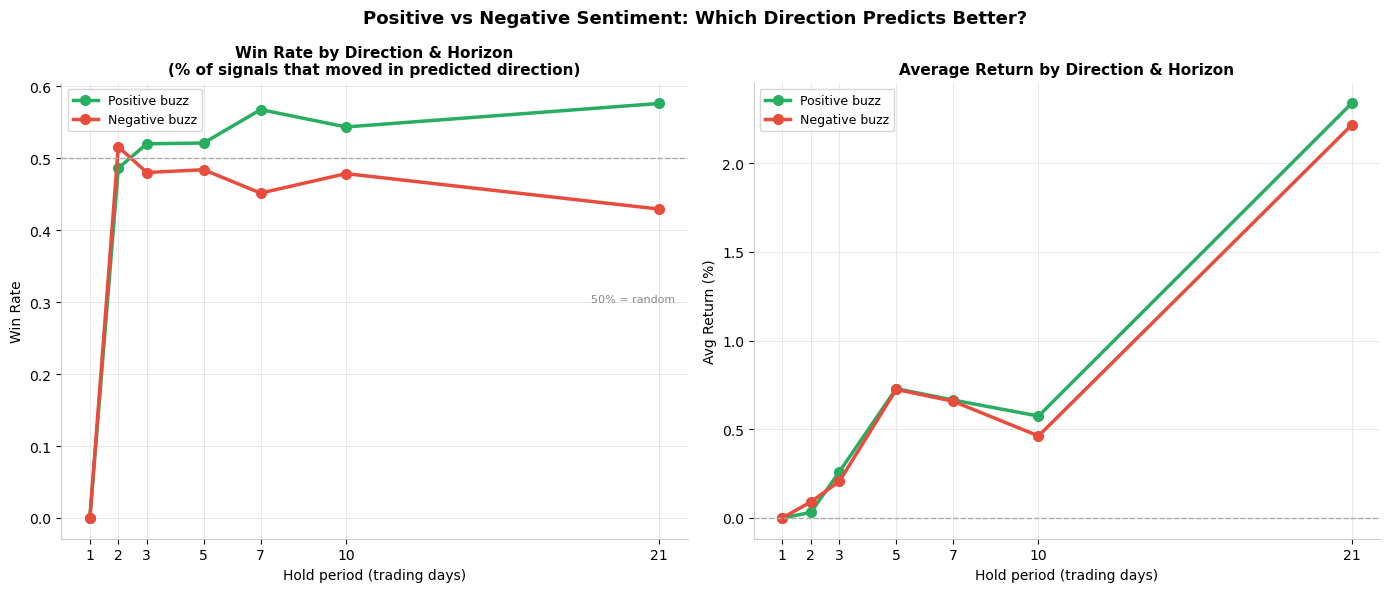


Win rate at 21-day hold by direction per ticker:
direction  negative  positive  stronger
ticker                                 
AAPL          0.374     0.608  positive
AMD           0.435     0.526  positive
AMZN          0.354     0.642  positive
COIN          0.790     0.170  negative
CRM           0.389     0.593  positive
CRWD          0.111     0.818  positive
DDOG          0.441     0.417  negative
GOOGL         0.367     0.645  positive
INTC          0.468     0.557  positive
MDB           0.605     0.312  negative
META          0.409     0.631  positive
MSFT          0.372     0.658  positive
NFLX          0.403     0.618  positive
NOW           0.376     0.604  positive
NVDA          0.363     0.660  positive
NVO           0.611     0.488  negative
OKTA          0.352     0.663  positive
PANW          0.559     0.646  positive
PLTR          0.312     0.786  positive
PM            0.326     0.600  positive
PYPL          0.490     0.492  positive
QCOM          0.564     0.549 

In [4]:
print('Computing directional signal quality ...')

dir_results = []

for ticker in all_tickers:
    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    if sig.empty or price.empty:
        continue

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    for direction in ['positive', 'negative']:
        if direction == 'positive':
            mask = sig['norm_sentiment'] >= SENTIMENT_THRESHOLD
        else:
            mask = sig['norm_sentiment'] <= -SENTIMENT_THRESHOLD

        sent_days = sig[mask]
        if len(sent_days) < 5:
            continue

        for horizon in [1, 2, 3, 5, 7, 10, 21]:
            rets = []
            for date, srow in sent_days.iterrows():
                future = price.index[price.index > date]
                if len(future) < horizon:
                    continue
                entry = price.loc[future[0], 'Close']
                exit_ = price.loc[future[horizon-1], 'Close']
                ret   = (exit_ - entry) / entry * 100
                rets.append(ret)

            if not rets:
                continue
            rets = np.array(rets)
            if direction == 'positive':
                win_rate = (rets > 0).mean()
            else:
                win_rate = (rets < 0).mean()  # negative buzz correct if price falls

            dir_results.append({
                'ticker'   : ticker,
                'direction': direction,
                'horizon'  : horizon,
                'win_rate' : round(win_rate, 4),
                'avg_ret'  : round(rets.mean(), 4),
                'n'        : len(rets),
            })

df_dir = pd.DataFrame(dir_results)
print(f'  {len(df_dir):,} direction x horizon x ticker combinations')

# Average win rate by direction and horizon
dir_summary = (
    df_dir.groupby(['direction', 'horizon'])
    .agg(avg_win_rate=('win_rate','mean'), avg_ret=('avg_ret','mean'), n=('n','sum'))
    .reset_index()
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

for ax, metric, label, title in [
    (axes[0], 'avg_win_rate', 'Win Rate', 'Win Rate by Direction & Horizon\n(% of signals that moved in predicted direction)'),
    (axes[1], 'avg_ret',      'Avg Return (%)', 'Average Return by Direction & Horizon'),
]:
    for direction, color in [('positive','#27ae60'), ('negative','#e74c3c')]:
        sub = dir_summary[dir_summary['direction']==direction]
        ax.plot(sub['horizon'], sub[metric], color=color, linewidth=2.5,
                marker='o', markersize=7, label=f'{direction.title()} buzz')
    ax.axhline(0.5 if metric=='avg_win_rate' else 0, color='#aaaaaa',
               linewidth=1, linestyle='--')
    if metric == 'avg_win_rate':
        ax.text(0.98, 0.52, '50% = random', transform=ax.transAxes,
                ha='right', fontsize=8, color='#888888')
    ax.set_xlabel('Hold period (trading days)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, facecolor='white')
    ax.set_facecolor('white')
    ax.set_xticks([1,2,3,5,7,10,21])

fig.suptitle('Positive vs Negative Sentiment: Which Direction Predicts Better?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-ticker summary
ticker_dir = (
    df_dir[df_dir['horizon']==21]
    .pivot_table(index='ticker', columns='direction',
                 values='win_rate', aggfunc='mean')
    .round(3)
)
ticker_dir['stronger'] = ticker_dir.apply(
    lambda r: 'positive' if r.get('positive',0) > r.get('negative',0) else 'negative', axis=1
)
print('\nWin rate at 21-day hold by direction per ticker:')
print(ticker_dir.to_string())
print('\nOverall: positive buzz is more predictive for', (ticker_dir['stronger']=='positive').sum(), 'tickers')
print('Overall: negative buzz is more predictive for', (ticker_dir['stronger']=='negative').sum(), 'tickers')

---
## 4. Missed Moves — Where Did the Stock Move Big but Sentiment Missed It?

Finds dates where a stock had an abnormal price move (z-score > 2.0)
but sentiment in the 7 days prior was flat or absent.
These are the blind spots — events HN didn't capture.

Finding missed moves ...
  Total big moves (z > 2.0): 4,153
  Captured by sentiment  : 1,258 (30.3%)
  Missed by sentiment    : 2,895 (69.7%)


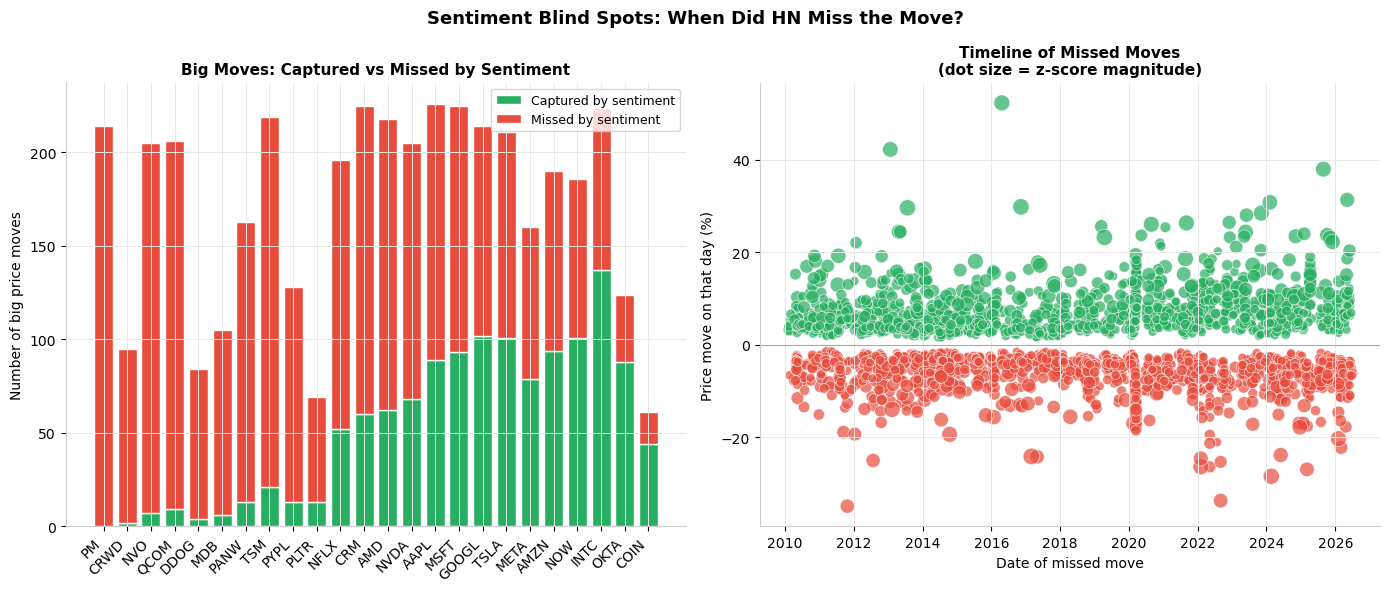


Top 10 biggest missed moves:
ticker       date  daily_return_pct  zscore  stories_prior_7d
  PANW 2017-03-01            -24.15   -7.05                 1
  PANW 2020-02-25            -17.01   -6.97                 0
  QCOM 2019-04-16             23.21    6.97                 1
  NVDA 2016-11-11             29.81    6.90                 6
  META 2013-07-25             29.61    6.84                 0
 GOOGL 2013-10-18             13.80    6.82                 0
   NVO 2013-02-11            -13.98   -6.77                 0
  PANW 2024-02-21            -28.44   -6.76                 1
  AMZN 2017-10-27             13.22    6.63                27
   AMD 2016-04-22             52.29    6.56                 0


In [5]:
print('Finding missed moves ...')

missed_rows = []

for ticker in all_tickers:
    price = df_prices[df_prices['ticker']==ticker].copy()
    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    if price.empty or sig.empty:
        continue

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    # Find big moves
    big_moves = price[price['zscore'].abs() >= ZSCORE_THRESHOLD]

    for date, mrow in big_moves.iterrows():
        # Look at sentiment in the 7 days prior
        prior_7 = sig.loc[(sig.index >= date - pd.Timedelta(days=7)) &
                          (sig.index < date), 'norm_sentiment'].dropna()

        avg_prior_sent = prior_7.mean() if len(prior_7) > 0 else np.nan
        max_prior_sent = prior_7.abs().max() if len(prior_7) > 0 else np.nan
        stories_prior  = sig.loc[(sig.index >= date - pd.Timedelta(days=7)) &
                                  (sig.index < date), 'story_count'].sum()

        # Missed if: big move but sentiment was quiet
        sentiment_quiet = (
            pd.isna(avg_prior_sent) or
            abs(avg_prior_sent) < SENTIMENT_THRESHOLD or
            stories_prior < 2
        )

        move_direction = 'up' if mrow['daily_return'] > 0 else 'down'

        missed_rows.append({
            'ticker'          : ticker,
            'date'            : date,
            'daily_return_pct': round(mrow['daily_return'] * 100, 2),
            'zscore'          : round(mrow['zscore'], 2),
            'move_direction'  : move_direction,
            'prior_sentiment' : round(avg_prior_sent, 4) if not pd.isna(avg_prior_sent) else None,
            'stories_prior_7d': int(stories_prior),
            'sentiment_missed': sentiment_quiet,
        })

df_missed = pd.DataFrame(missed_rows)
df_missed['date'] = pd.to_datetime(df_missed['date'])

big_moves_total  = len(df_missed)
missed_total     = df_missed['sentiment_missed'].sum()
captured_total   = big_moves_total - missed_total

print(f'  Total big moves (z > {ZSCORE_THRESHOLD}): {big_moves_total:,}')
print(f'  Captured by sentiment  : {captured_total:,} ({captured_total/big_moves_total:.1%})')
print(f'  Missed by sentiment    : {missed_total:,} ({missed_total/big_moves_total:.1%})')

# Plot missed vs captured by ticker
miss_summary = df_missed.groupby('ticker').agg(
    total_moves = ('date','count'),
    missed      = ('sentiment_missed','sum'),
).reset_index()
miss_summary['captured'] = miss_summary['total_moves'] - miss_summary['missed']
miss_summary['miss_rate'] = miss_summary['missed'] / miss_summary['total_moves']
miss_summary = miss_summary.sort_values('miss_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

ax = axes[0]
x  = range(len(miss_summary))
ax.bar(x, miss_summary['captured'], color='#27ae60', label='Captured by sentiment', edgecolor='white')
ax.bar(x, miss_summary['missed'], bottom=miss_summary['captured'],
       color='#e74c3c', label='Missed by sentiment', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(miss_summary['ticker'], rotation=45, ha='right')
ax.set_ylabel('Number of big price moves', fontsize=10)
ax.set_title('Big Moves: Captured vs Missed by Sentiment', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.set_facecolor('white')

ax = axes[1]
# Timeline of missed moves
missed_only = df_missed[df_missed['sentiment_missed']]
ax.scatter(missed_only['date'], missed_only['daily_return_pct'],
           c=['#27ae60' if v>0 else '#e74c3c' for v in missed_only['daily_return_pct']],
           alpha=0.7, s=abs(missed_only['zscore'])*20, edgecolors='white', linewidths=0.5)
ax.axhline(0, color='#aaaaaa', linewidth=0.8)
ax.set_xlabel('Date of missed move', fontsize=10)
ax.set_ylabel('Price move on that day (%)', fontsize=10)
ax.set_title('Timeline of Missed Moves\n(dot size = z-score magnitude)',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_facecolor('white')

fig.suptitle('Sentiment Blind Spots: When Did HN Miss the Move?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 biggest missed moves:')
print(df_missed[df_missed['sentiment_missed']]
      .sort_values('zscore', key=abs, ascending=False)
      .head(10)[['ticker','date','daily_return_pct','zscore','stories_prior_7d']]
      .to_string(index=False))

---
## 5. Cross-Company Sentiment Spillover

For every pair of companies (A's sentiment → B's price), computes rolling 90-day
Pearson correlation. Finds pairs that are consistently strong across time.

**No assumptions about which pairs should be related — let the data decide.**

In [6]:
SPILLOVER_WINDOW = 90    # days for rolling correlation
MIN_PERIODS      = 30    # minimum data points in window
SPILLOVER_HORIZON = 5   # trading days forward for price return

print(f'Computing cross-company spillover ({SPILLOVER_WINDOW}-day rolling window) ...')
print('This may take several minutes for all pairs.')

# Build daily series: sentiment per ticker, forward return per ticker
all_dates = pd.date_range(
    daily_signals['date'].min(),
    daily_signals['date'].max(), freq='D'
)

# Pivot sentiment and forward returns to wide format
sent_wide = daily_signals.pivot_table(
    index='date', columns='ticker', values='norm_sentiment'
)

# Build forward return series per ticker
fwd_wide_rows = {}
for ticker in all_tickers:
    price = df_prices[df_prices['ticker']==ticker].copy()
    if price.empty: continue
    price = price.set_index('Date').sort_index()
    # Forward return = price SPILLOVER_HORIZON days later
    fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)
    fwd_wide_rows[ticker] = fwd

fwd_wide = pd.DataFrame(fwd_wide_rows)
fwd_wide.index = pd.to_datetime(fwd_wide.index)

# Compute rolling correlation for each (sentiment_ticker, price_ticker) pair
sent_tickers  = sent_wide.columns.tolist()
price_tickers = fwd_wide.columns.tolist()

spillover_rows = []

for st in sent_tickers:
    sent_series = sent_wide[st].dropna()
    for pt in price_tickers:
        if st == pt:
            continue  # skip self-correlation
        price_series = fwd_wide[pt].dropna()

        # Align
        combined = pd.concat([sent_series.rename('sent'),
                               price_series.rename('ret')], axis=1).dropna()
        if len(combined) < MIN_PERIODS * 2:
            continue

        # Rolling correlation
        roll_corr = combined['sent'].rolling(SPILLOVER_WINDOW, min_periods=MIN_PERIODS)\
                                    .corr(combined['ret'])

        avg_corr  = roll_corr.mean()
        max_corr  = roll_corr.max()
        pct_pos   = (roll_corr > 0.2).mean()  # fraction of windows with strong positive corr
        pct_neg   = (roll_corr < -0.2).mean()

        spillover_rows.append({
            'sent_ticker' : st,
            'price_ticker': pt,
            'avg_corr'    : round(avg_corr, 4),
            'max_corr'    : round(max_corr, 4),
            'pct_pos_windows': round(pct_pos, 3),
            'pct_neg_windows': round(pct_neg, 3),
        })

df_spillover = pd.DataFrame(spillover_rows).dropna(subset=['avg_corr'])
print(f'  Spillover matrix: {len(df_spillover):,} pairs computed')

# Top positive spillover pairs
top_pairs = df_spillover.sort_values('avg_corr', ascending=False).head(20)
print('\nTop 20 cross-company spillover pairs (A sentiment -> B price):')
print(top_pairs[['sent_ticker','price_ticker','avg_corr','pct_pos_windows']].to_string(index=False))

Computing cross-company spillover (90-day rolling window) ...
This may take several minutes for all pairs.


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_61827/2756723561.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = price['Close'].pct_change(SPILLOVER_HORIZON).shift(-SPILLOVER_HORIZON)


  Spillover matrix: 576 pairs computed

Top 20 cross-company spillover pairs (A sentiment -> B price):
sent_ticker price_ticker  avg_corr  pct_pos_windows
         PM         OKTA    0.2721            0.663
        NVO        GOOGL    0.2165            0.544
       PLTR         PYPL    0.2139            0.372
       PANW         DDOG    0.2062            0.306
         PM         CRWD    0.1979            0.429
         PM         PLTR    0.1958            0.233
        NVO         PYPL    0.1822            0.184
       QCOM         OKTA    0.1684            0.263
        NVO          AMD    0.1657            0.136
       PLTR         OKTA    0.1632            0.193
       PLTR         COIN    0.1613            0.120
       DDOG         PANW    0.1549            0.039
       PANW        GOOGL    0.1545            0.152
        TSM         PYPL    0.1482            0.395
       PANW          NOW    0.1473            0.039
       SNOW          MDB    0.1459            0.219
       PLTR  

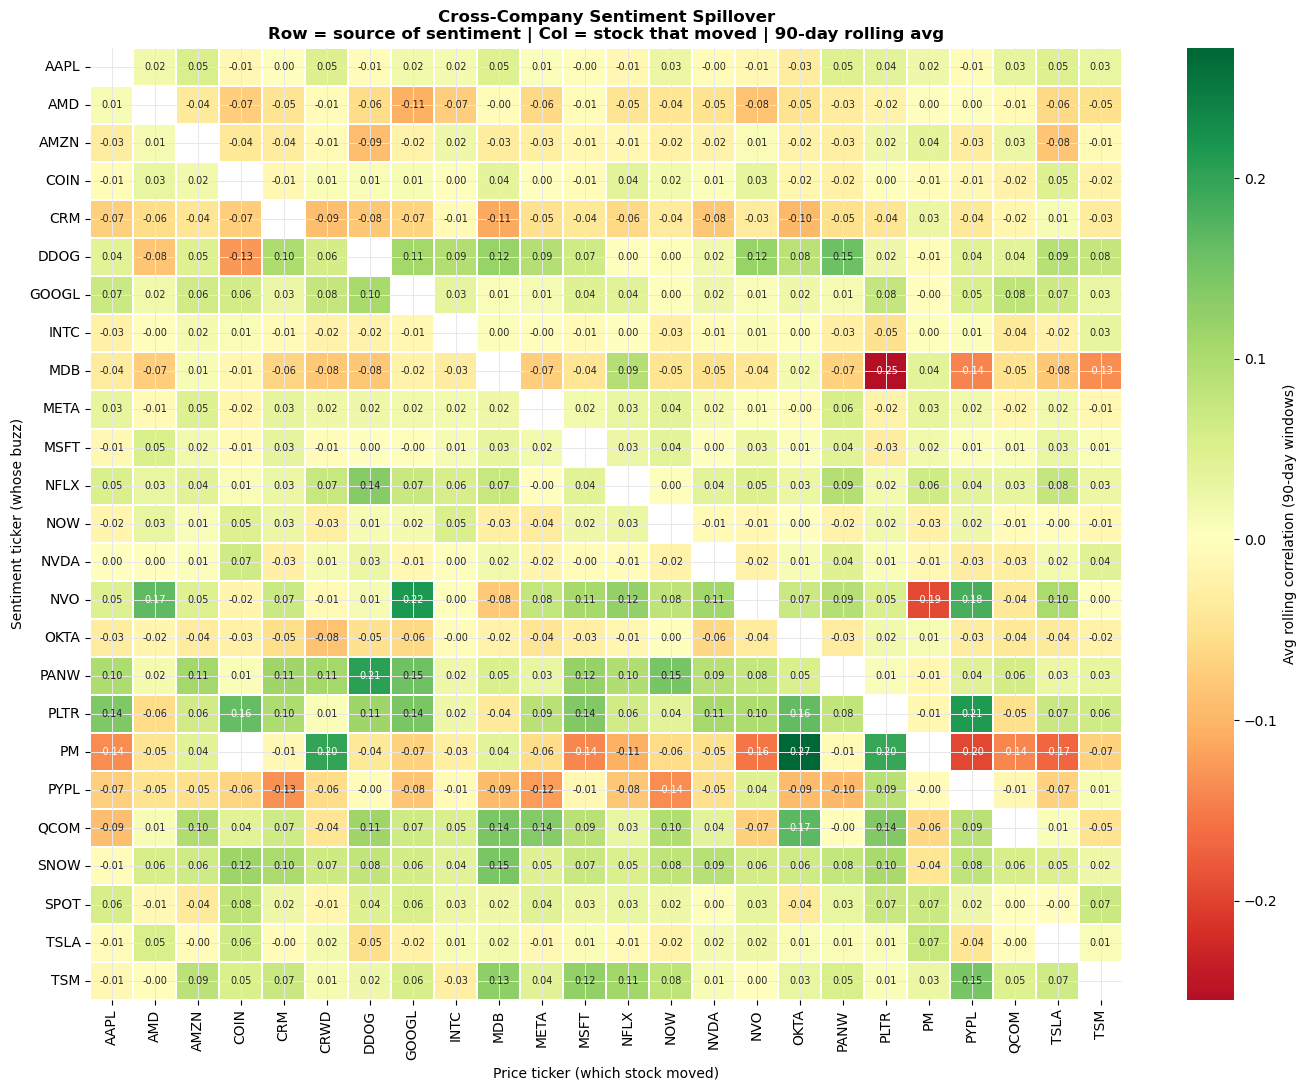


Most consistently correlated pairs (relationship held in 40%+ of windows):
sent_ticker price_ticker  avg_corr  pct_pos_windows  pct_neg_windows
         PM         OKTA    0.2721            0.663            0.000
        MDB         PLTR   -0.2547            0.000            0.578
        NVO        GOOGL    0.2165            0.544            0.000
         PM         CRWD    0.1979            0.429            0.000
        TSM          MDB    0.1296            0.414            0.008


In [7]:
# Heatmap of average spillover correlations
pivot_spill = df_spillover.pivot_table(
    index='sent_ticker', columns='price_ticker', values='avg_corr'
)

fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')
sns.heatmap(
    pivot_spill, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Avg rolling correlation (90-day windows)'},
    annot_kws={'size': 7}
)
ax.set_title(
    f'Cross-Company Sentiment Spillover\n'
    f'Row = source of sentiment | Col = stock that moved | {SPILLOVER_WINDOW}-day rolling avg',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Price ticker (which stock moved)', fontsize=10)
ax.set_ylabel('Sentiment ticker (whose buzz)', fontsize=10)
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

# Find pairs that are consistently correlated across time
consistent_pairs = df_spillover[
    (df_spillover['pct_pos_windows'] >= 0.4) |
    (df_spillover['pct_neg_windows'] >= 0.4)
].sort_values('avg_corr', key=abs, ascending=False).head(15)

print('\nMost consistently correlated pairs (relationship held in 40%+ of windows):')
print(consistent_pairs[['sent_ticker','price_ticker','avg_corr',
                          'pct_pos_windows','pct_neg_windows']].to_string(index=False))

---
## 6. Sector Label Quality

Measures two things per sector:
1. **Intra-sector sentiment coherence** — do companies in this sector get talked about together?
2. **Sentiment-to-return correlation** — does the sector's buzz actually predict its returns?

High on both = well-defined, useful sector grouping.
High coherence but low correlation = companies move together but buzz doesn't predict it.
Low coherence but high correlation = buzz predicts returns but companies aren't talked about as a group.

Computing sector label quality ...
          sector  n_tickers  sent_coherence  price_coherence  sent_to_ret_corr  sent_to_ret_pval
      AI / Chips          4          0.0726           0.4445            0.0175            0.5117
        Big Tech          5          0.0477           0.4745            0.0525            0.0417
Fintech / Crypto          2         -0.0219           0.4487            0.0006            0.9843
    Cloud / SaaS          4          0.0047           0.5807           -0.0324            0.2181


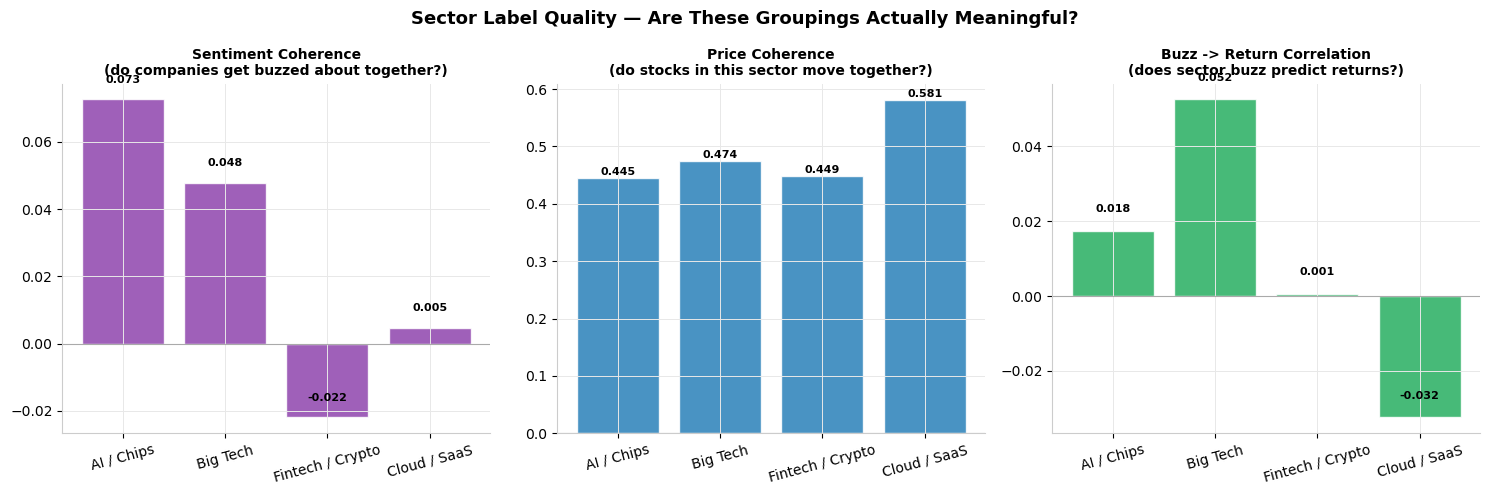


Interpretation:
  High sent_coherence  = companies in this sector are talked about together
  High price_coherence = stocks in this sector move together
  High sent_to_ret     = buzz about this sector predicts sector returns
  Best sector for trading = high on all three
  Consider splitting sectors that are low on coherence but high on sent_to_ret


In [8]:
print('Computing sector label quality ...')

sector_quality = []

for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in all_tickers and t in fwd_wide.columns]
    if len(available) < 2:
        continue

    # 1. Intra-sector sentiment coherence
    # Average pairwise correlation of sentiment series within sector
    sent_sub = sent_wide[available].dropna(how='all')
    pairwise = []
    for i, ta in enumerate(available):
        for tb in available[i+1:]:
            both = sent_sub[[ta, tb]].dropna()
            if len(both) > 30:
                r, _ = stats.pearsonr(both[ta], both[tb])
                pairwise.append(r)
    coherence = np.mean(pairwise) if pairwise else np.nan

    # 2. Sector sentiment to sector return correlation
    sector_sent_series = sent_wide[available].mean(axis=1).dropna()
    sector_ret_series  = fwd_wide[available].mean(axis=1).dropna()
    both = pd.concat([sector_sent_series.rename('sent'),
                      sector_ret_series.rename('ret')], axis=1).dropna()
    if len(both) > 30:
        r_sent_ret, p_sent_ret = stats.pearsonr(both['sent'], both['ret'])
    else:
        r_sent_ret = p_sent_ret = np.nan

    # 3. Intra-sector price coherence
    price_sub = fwd_wide[available].dropna(how='all')
    price_pairs = []
    for i, ta in enumerate(available):
        for tb in available[i+1:]:
            both_p = price_sub[[ta, tb]].dropna()
            if len(both_p) > 30:
                r, _ = stats.pearsonr(both_p[ta], both_p[tb])
                price_pairs.append(r)
    price_coherence = np.mean(price_pairs) if price_pairs else np.nan

    sector_quality.append({
        'sector'            : sector,
        'n_tickers'         : len(available),
        'sent_coherence'    : round(coherence, 4),
        'price_coherence'   : round(price_coherence, 4),
        'sent_to_ret_corr'  : round(r_sent_ret, 4),
        'sent_to_ret_pval'  : round(p_sent_ret, 4),
    })

df_quality = pd.DataFrame(sector_quality)
print(df_quality.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

metrics = [
    ('sent_coherence',  'Sentiment Coherence\n(do companies get buzzed about together?)', '#8e44ad'),
    ('price_coherence', 'Price Coherence\n(do stocks in this sector move together?)',     '#2980b9'),
    ('sent_to_ret_corr','Buzz -> Return Correlation\n(does sector buzz predict returns?)', '#27ae60'),
]

for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.bar(df_quality['sector'], df_quality[col],
                  color=color, edgecolor='white', alpha=0.85)
    ax.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_facecolor('white')
    ax.tick_params(axis='x', labelrotation=15)
    for bar, val in zip(bars, df_quality[col]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005,
                    f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

fig.suptitle('Sector Label Quality — Are These Groupings Actually Meaningful?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  High sent_coherence  = companies in this sector are talked about together')
print('  High price_coherence = stocks in this sector move together')
print('  High sent_to_ret     = buzz about this sector predicts sector returns')
print('  Best sector for trading = high on all three')
print('  Consider splitting sectors that are low on coherence but high on sent_to_ret')

---
## 7. Refined Sector Suggestions

Based on the spillover matrix and sector quality scores, suggests:
- Which sectors should be split into smaller, more coherent groups
- Which companies from different sectors actually move together
- A refined sector map to try in the combined strategy

In [9]:
print('Generating refined sector suggestions ...')

# Find clusters of companies with high mutual spillover
# For each company, find its top 3 spillover targets
top_spillover = (
    df_spillover
    .sort_values('avg_corr', ascending=False)
    .groupby('sent_ticker')
    .head(3)
    .reset_index(drop=True)
)

print('Top spillover targets per company (whose price moves when this company gets buzz):')
print(top_spillover[['sent_ticker','price_ticker','avg_corr']]
      .sort_values('sent_ticker').to_string(index=False))

# Sectors ranked by usefulness
df_quality_ranked = df_quality.copy()
df_quality_ranked['overall_score'] = (
    df_quality_ranked['sent_coherence'].fillna(0) +
    df_quality_ranked['price_coherence'].fillna(0) +
    df_quality_ranked['sent_to_ret_corr'].abs().fillna(0)
).round(4)
df_quality_ranked = df_quality_ranked.sort_values('overall_score', ascending=False)

print('\nSector ranking by overall usefulness:')
print(df_quality_ranked[['sector','overall_score','sent_coherence',
                           'price_coherence','sent_to_ret_corr']].to_string(index=False))

best_sector  = df_quality_ranked.iloc[0]['sector']
worst_sector = df_quality_ranked.iloc[-1]['sector']
print(f'\nBest-defined sector  : {best_sector}')
print(f'Least useful sector  : {worst_sector} — consider splitting or redefining')

# Suggest splitting worst sector based on spillover patterns
worst_tickers = SECTORS.get(worst_sector, [])
worst_spill = df_spillover[
    (df_spillover['sent_ticker'].isin(worst_tickers)) &
    (df_spillover['price_ticker'].isin(worst_tickers))
].sort_values('avg_corr', ascending=False)

if not worst_spill.empty:
    print(f'\nIntra-sector spillover within {worst_sector}:')
    print(worst_spill[['sent_ticker','price_ticker','avg_corr']].to_string(index=False))
    print('\nCompanies with low mutual spillover may belong in different sectors.')

Generating refined sector suggestions ...
Top spillover targets per company (whose price moves when this company gets buzz):
sent_ticker price_ticker  avg_corr
       AAPL         PANW    0.0477
       AAPL         CRWD    0.0484
       AAPL         AMZN    0.0543
        AMD           PM    0.0013
        AMD         PYPL    0.0021
        AMD         AAPL    0.0124
       AMZN         QCOM    0.0257
       AMZN           PM    0.0367
       AMZN         INTC    0.0232
       COIN         TSLA    0.0458
       COIN         NFLX    0.0380
       COIN          MDB    0.0360
        CRM         TSLA    0.0110
        CRM         INTC   -0.0084
        CRM           PM    0.0267
       DDOG          NVO    0.1195
       DDOG          MDB    0.1179
       DDOG         PANW    0.1549
      GOOGL         DDOG    0.1049
      GOOGL         QCOM    0.0812
      GOOGL         CRWD    0.0764
       INTC         AMZN    0.0156
       INTC         COIN    0.0099
       INTC          TSM    0.0314
